### Installing Packages and Dependencies

```
conda create -n interpretabnet python=3.10
conda activate interpretabnet
```

```
pip install -r requirements.txt
```

### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import json
# import wget
import math

from datasets import load_from_disk

from pathlib import Path
from matplotlib import pyplot as plt
# from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
np.random.seed(0)

/data2/users/ij23/anaconda3/envs/vpud/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Processing

Create a directory named "data" within InterpreTabNet.

```
mkdir data
```

Download and place your desired dataset into /InterpreTabNet/data.

Modify the below according to the comments to process your dataset. The following is an example for the "Adult" dataset.

In [3]:
dataset = 'income' # Modify Dataset Name

# out = Path(os.getcwd() + '/data/' + dataset + '.csv')
# train = pd.read_csv(out)

data_path = f'TabLLM/datasets_serialized/{dataset}'

f = open(f'{data_path}/info.json')
label_map = json.load(f)
label_name = label_map['label']
labels = label_map['map']
label_keys = list(labels)

data = load_from_disk(data_path)
data = data.to_pandas()


In [4]:
# Replace The and is with =, remove extra spaces
data['note'] = (data['note']
                  .str.replace(r'\bThe\b', '', regex=True)
                  .str.replace(r'\bis\b', '=', regex=True)
                  .str.replace(r'\s{2,}', ' ', regex=True)
                  .str.lstrip())

# Function to parse the 'note' string into a dictionary of features
def parse_note_to_features(note, feature=None):
    features = {}
    for feature_str in note.strip('.').split('. '):
        key_value = feature_str.split(' = ')
        if len(key_value) == 2:
            key, value = key_value
            features[key.strip()] = value.strip()
            
    if feature:
        return features.get(feature.strip(), None)
    
    return features

# Apply the function to the 'note' column and expand the dictionaries into columns
tmp_combined_data_note = data['note']
note2features = data['note'].apply(parse_note_to_features).apply(pd.Series)
feature_columns = note2features.columns
print("Features:", feature_columns)

Features: Index(['Age', 'Race', 'Sex', 'Marital status',
       'Relation to head of the household', 'Native country', 'Occupation',
       'Work class', 'Capital gain last year', 'Capital loss last year',
       'Education', 'Work hours per week'],
      dtype='object')


In [5]:
column_dtypes = {}

for feature in feature_columns:
    try:
        if note2features.iloc[0][feature].isdigit():
            column_dtypes.update({feature: float})
    except:
        pass

note2features = note2features.astype(column_dtypes)

label_series = data["label"].astype(bool).astype(float)

In [6]:
def standardization(df, column_name):
    mean_value = df[column_name].mean()
    std_value = df[column_name].std()
    print(f"feature: {column_name}; mean: {mean_value}; std: {std_value}")
    df[column_name] = (df[column_name] - mean_value) / std_value
    
for feature, dtype in column_dtypes.items():
    if dtype == float:
        standardization(note2features, feature)

feature: Age; mean: 38.64358543876172; std: 13.710509934443555
feature: Capital gain last year; mean: 1079.0676262233324; std: 7452.019057655394
feature: Capital loss last year; mean: 87.50231358257237; std: 403.00455212435907
feature: Work hours per week; mean: 40.422382375824085; std: 12.391444024252307


In [7]:
full_dataset = pd.concat([note2features, label_series], axis=1)

In [8]:
# dataset = 'income' # Modify Dataset Name

# # out = Path(os.getcwd() + '/data/' + dataset + '.csv')
# # train = pd.read_csv(out)

# data_path = f'TabLLM/datasets_serialized/{dataset}'

# f = open(f'{data_path}/info.json')
# label_map = json.load(f)
# label_name = label_map['label']
# labels = label_map['map']
# label_keys = list(labels)

# train = load_from_disk(data_path)
# train = train.to_pandas()

# target = label_name # Modify Target Name

# if "Set" not in train.columns:
#     train["Set"] = np.random.choice(["train", "valid", "test"], p=[.8, .1, .1], size=(train.shape[0],))

# train_indices = train[train.Set == "train"].index
# valid_indices = train[train.Set == "valid"].index
# test_indices = train[train.Set == "test"].index

# nunique = train.nunique()
# types = train.dtypes


In [9]:

# categorical_columns = []
# categorical_dims = {}
# for col in full_dataset.columns:
#     if types[col] == 'object' or nunique[col] < 200:
#         print(col, full_dataset[col].nunique())
#         l_enc = LabelEncoder()
#         full_dataset[col] = full_dataset[col].fillna("nan")
#         full_dataset[col] = l_enc.fit_transform(full_dataset[col].values)
#         categorical_columns.append(col)
#         categorical_dims[col] = len(l_enc.classes_)
#     else:
#         full_dataset.fillna(full_dataset.loc[train_indices, col].mean(), inplace=True)

# # Setting the target as a categorical feature
# full_dataset.loc[full_dataset[label_name] == 0, label_name] = "wealthy"
# full_dataset.loc[full_dataset[label_name] == 1, label_name] = "not_wealthy"

# cat_idxs = [i for i, f in enumerate(features) if f in categorical_columns]

# cat_dims = [categorical_dims[f] for i, f in enumerate(features) if f in categorical_columns]

In [10]:
types = full_dataset.dtypes
categorical_features = [feature for feature, dtype in types.items() if dtype != float]
target = "label"

index_series = pd.Series(np.random.choice(["train", "valid", "test"], p=[.8, .1, .1], size=(full_dataset.shape[0],)))

nunique = full_dataset.nunique()

train_indices = full_dataset[index_series == "train"].index
valid_indices = full_dataset[index_series == "valid"].index
test_indices = full_dataset[index_series == "test"].index

full_dataset = pd.get_dummies(full_dataset, prefix=categorical_features).astype(float)

unused_feat = ['Set']

features = [col for col in full_dataset.columns if col not in unused_feat + [target]]

X_train = full_dataset[features].values[train_indices]
y_train = full_dataset[target].values[train_indices]

X_valid = full_dataset[features].values[valid_indices]
y_valid = full_dataset[target].values[valid_indices]

X_test = full_dataset[features].values[test_indices]
y_test = full_dataset[target].values[test_indices]

In [11]:
X_train.shape

(39130, 99)

### Logistic Regression

In [12]:
from scipy.special import expit
import scipy.stats

In [13]:
# probability of y

def y_prob(bias: np.float64, parameters: np.ndarray, x: np.ndarray):
    return expit(bias + np.matmul(x, parameters))

In [14]:
# Likelihood

def log_likelihood(bias: np.float64, parameters: np.ndarray, x: np.ndarray, y: np.ndarray):
    p = expit(bias + np.matmul(x, parameters))
    log_likelihood = np.dot(y, np.log(p)) + np.dot((1-y), np.log(1-p))
    return log_likelihood

In [15]:
# Prior

def log_prior(bias: np.float64, parameters: np.ndarray):
    return scipy.stats.norm.logpdf(bias) + np.sum(scipy.stats.norm.logpdf(parameters))

In [16]:
# Sample proposal

def sample_proposal(bias_old: np.ndarray, parameters_old: np.ndarray, proposal_std=1):
    bias_new = scipy.stats.norm().rvs()*proposal_std + bias_old
    parameters_new = scipy.stats.norm().rvs(size=parameters_old.size)*proposal_std + parameters_old
    return bias_new, parameters_new

In [17]:
# Acceptance function

def acceptance_log_prob(x, y, bias_old, parameters_old, bias_new, parameters_new):
    new_posterior = log_likelihood(bias_new, parameters_new, x, y) + log_prior(bias_new, parameters_new)
    old_posterior = log_likelihood(bias_old, parameters_old, x, y) + log_prior(bias_old, parameters_old)
    return new_posterior - old_posterior 

In [18]:
# Metropolis-Hastings step

def metropolis_hastings_step(x, y, bias, parameters, proposal_std=1):
    bias_new, parameters_new = sample_proposal(bias, parameters, proposal_std)
    log_prob = acceptance_log_prob(x, y, bias, parameters, bias_new, parameters_new)
    
    if log_prob > 0:
        return bias_new, parameters_new
    elif scipy.stats.uniform.rvs() < np.exp(log_prob):
        return bias_new, parameters_new
    else:
        return bias, parameters

In [19]:
num_iterations = 10000
proposal_std = 0.01

parameter_dim = X_train.shape[1]


##### Single Chain

In [20]:
bias = scipy.stats.norm.rvs()
parameters = scipy.stats.norm.rvs(size=parameter_dim)

bias_list = [bias]
parameters_list = [parameters]
train_likelihood_list = []
test_likelihood_list = []

for i in range(num_iterations):
    bias, parameters = metropolis_hastings_step(X_train, y_train, bias, parameters, proposal_std=0.01)
    bias_list.append(bias)
    parameters_list.append(parameters)
    train_likelihood_list.append(log_likelihood(bias, parameters, X_train, y_train))
    test_likelihood_list.append(log_likelihood(bias, parameters, X_test, y_test))
    

/tmp/ipykernel_3312101/1616978322.py:5: RuntimeWarning: divide by zero encountered in log
  log_likelihood = np.dot(y, np.log(p)) + np.dot((1-y), np.log(1-p))


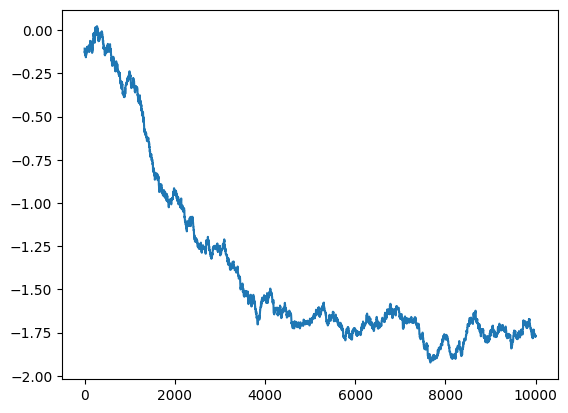

In [21]:
fig, ax = plt.subplots()

plt.plot(np.arange(num_iterations+1), bias_list)

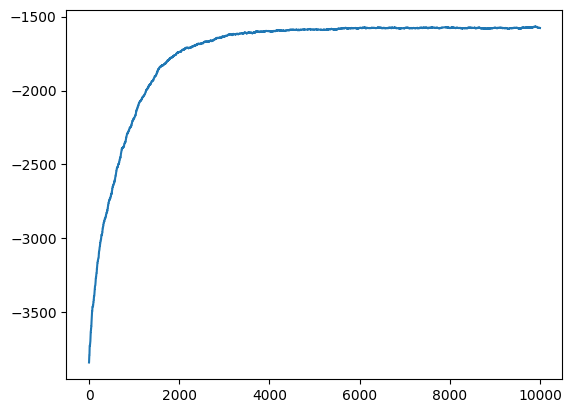

In [22]:
fig, ax = plt.subplots()

plt.plot(np.arange(num_iterations), test_likelihood_list)

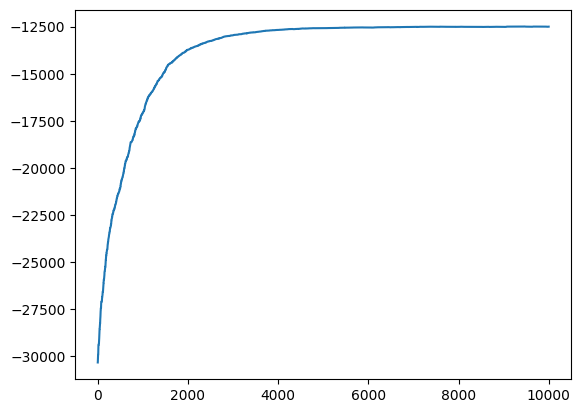

In [23]:
plt.plot(np.arange(num_iterations), train_likelihood_list)

##### Multiple Chains

In [24]:
def mcmc_chain(x, y, num_iterations, proposal_std):
    bias = scipy.stats.norm.rvs()
    parameters = scipy.stats.norm.rvs(size=parameter_dim)

    bias_list = [bias]
    parameters_list = [parameters]

    for _ in range(num_iterations-1):
        bias, parameters = metropolis_hastings_step(x, y, bias, parameters, proposal_std)
        bias_list.append(bias)
        parameters_list.append(parameters)
        
    return bias_list, parameters_list
        

In [25]:
num_chains = 5

chains = []

for _ in range(num_chains):
    bias_list, parameters_list = mcmc_chain(X_train, y_train, num_iterations, proposal_std)
    chains.append({"bias": bias_list, "parameters": parameters_list})
    


/tmp/ipykernel_3312101/1616978322.py:5: RuntimeWarning: divide by zero encountered in log
  log_likelihood = np.dot(y, np.log(p)) + np.dot((1-y), np.log(1-p))


In [26]:
burn_in = 4000
lag = 100

full_bias_list = []
full_parameter_list = []

for i in range(num_chains):
    full_bias_list += chains[i]["bias"][burn_in::lag]
    full_parameter_list += chains[i]["parameters"][burn_in::lag]
    
bias_array = np.array(full_bias_list)
parameter_array = np.array(full_parameter_list)

In [27]:
sample_size = len(bias_array)


In [28]:
y_probs = y_prob(bias_array[0], parameter_array[0], X_test)

y_pred = (scipy.stats.uniform.rvs(y_probs.shape) < y_probs).astype(float)
print(np.mean((y_pred==y_test)))

0.7631848963677406


In [44]:
def y_pred(x, bias_sample, parameter_sample):
    y_probs_list = []
    y_pred_list = []
    for i in range(len(bias_sample)):
        y_probs = y_prob(bias_sample[i], parameter_sample[i], x)

        y_pred = (scipy.stats.uniform.rvs(size=y_probs.shape) < y_probs).astype(float)
        
        y_probs_list.append(y_probs)
        y_pred_list.append(y_pred)
        
    return np.array(y_probs_list), np.array(y_pred_list)

In [45]:
y_probs_test, y_pred_test = y_pred(X_test, bias_array, parameter_array)

In [46]:
y_pred_test.shape

(300, 4873)

In [48]:
# Total test accuracy

print(f"Test accuracy: {np.mean(y_pred_test == y_test)}")

Test accuracy: 0.7960824953827211


In [56]:
def binary_entropy(p):
    return - p*np.log2(p) - (1 - p)*np.log2(1-p)

In [59]:
# Total entropy

total_entropy = binary_entropy(np.mean(y_pred_test, axis=0))

print(total_entropy)

[0.81127812 0.03223036 0.42524461 ... 0.2108423  0.99948698 0.69444607]


/tmp/ipykernel_3312101/1369209820.py:2: RuntimeWarning: divide by zero encountered in log2
  return - p*np.log2(p) - (1 - p)*np.log2(1-p)
/tmp/ipykernel_3312101/1369209820.py:2: RuntimeWarning: invalid value encountered in multiply
  return - p*np.log2(p) - (1 - p)*np.log2(1-p)


In [61]:
# Aleatoric uncertainty

conditional_entropy = np.mean(binary_entropy(y_probs_test), axis=0)

print(conditional_entropy)

[0.75669709 0.02631999 0.48783251 ... 0.1242201  0.99704257 0.74051873]


In [63]:
# Mutual information

mutual_information = total_entropy - conditional_entropy

print(mutual_information)

[ 0.05458103  0.00591037 -0.0625879  ...  0.0866222   0.00244441
 -0.04607266]


In [82]:
x_index = 0

print(f"Uncertainty decomposition (Total = U_A + U_E): {total_entropy[x_index]} = {conditional_entropy[x_index]} + {mutual_information[x_index]}")

Uncertainty decomposition (Total = U_A + U_E): 0.8112781244591328 = 0.756697092934823 + 0.05458103152430982


Text(0.5, 1.0, 'Conditional Entropy (Aleatoric uncertainty)')

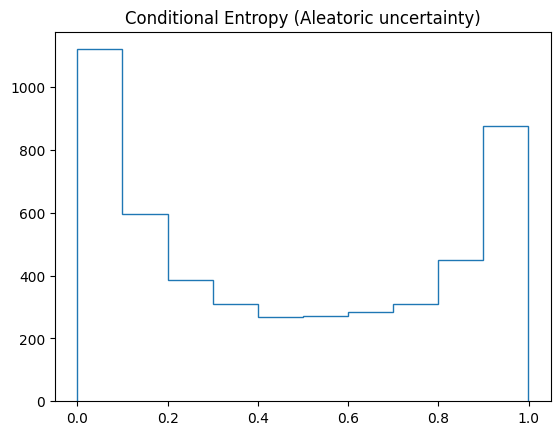

In [70]:
counts, bins = np.histogram(conditional_entropy)
plt.stairs(counts, bins)
plt.title("Conditional Entropy (Aleatoric uncertainty)")